In [108]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import GridSearchCV

In [109]:
df_gym = pd.read_csv("S:\courses\my DS\Hello world\kaggle\gym\gym_members_dataset.csv")

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\drinkwater\AppData\Local\Temp\ipykernel_21192\2791918896.py:1: SyntaxWarning: invalid escape sequence '\c'
  df_gym = pd.read_csv("S:\courses\my DS\Hello world\kaggle\gym\gym_members_dataset.csv")


In [110]:
df_gym.head()

,Member_ID,Name,Age,Gender,Address,Phone_Number,Membership_Type,Join_Date,Last_Visit_Date,Favorite_Exercise,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn
0,1,NaN,19.0,Male,"Street 171, City 39",032-51510359,Quarterly,2022-07-23,2022-11-03,Pull-ups,93,214.0,13995.0,18.0,No
1,2,Shanza,19.0,Female,"Street 111, City 18",039-19243328,Monthly,2023-12-04,2024-02-14,Squats,37,436.0,4612.0,11.0,No
2,3,Ubaidullah,52.0,Male,"Street 69, City 21",033-60221501,Quarterly,2024-09-13,2024-12-07,Bench Press,98,523.0,3124.0,4.0,Yes
3,4,Mansoor Ahmed,52.0,Male,"Street 72, City 39",035-55527902,Monthly,2024-06-05,2025-02-24,Pull-ups,66,282.0,4586.0,24.0,No
4,5,Hanzala,32.0,Male,"Street 6, City 12",038-93946322,Monthly,2022-06-15,2022-12-02,Bench Press,32,522.0,16353.0,18.0,No


In [111]:
df_gym.shape

(150, 15)

In [112]:
df_gym.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Member_ID                 150 non-null    int64  
 1   Name                      127 non-null    object 
 2   Age                       137 non-null    float64
 3   Gender                    150 non-null    object 
 4   Address                   150 non-null    object 
 5   Phone_Number              150 non-null    object 
 6   Membership_Type           150 non-null    object 
 7   Join_Date                 141 non-null    object 
 8   Last_Visit_Date           150 non-null    object 
 9   Favorite_Exercise         150 non-null    object 
 10  Avg_Workout_Duration_Min  150 non-null    int64  
 11  Avg_Calories_Burned       139 non-null    float64
 12  Total_Weight_Lifted_kg    142 non-null    float64
 13  Visits_Per_Month          138 non-null    float64
 14  Churn     

In [113]:
df_gym.isna().sum()

Member_ID                    0
Name                        23
Age                         13
Gender                       0
Address                      0
Phone_Number                 0
Membership_Type              0
Join_Date                    9
Last_Visit_Date              0
Favorite_Exercise            0
Avg_Workout_Duration_Min     0
Avg_Calories_Burned         11
Total_Weight_Lifted_kg       8
Visits_Per_Month            12
Churn                        0
dtype: int64

In [114]:
mean_age = df_gym["Age"].mean()
df_gym["Age"].fillna(mean_age, inplace=True)

C:\Users\drinkwater\AppData\Local\Temp\ipykernel_21192\1480045426.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_gym["Age"].fillna(mean_age, inplace=True)


In [115]:
df_gym["Age"] = df_gym["Age"].astype(int)

In [116]:
mean_Avg_Calories_Burned = df_gym["Avg_Calories_Burned"].mean()
df_gym["Avg_Calories_Burned"].fillna(mean_Avg_Calories_Burned, inplace=True)

C:\Users\drinkwater\AppData\Local\Temp\ipykernel_21192\225390241.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_gym["Avg_Calories_Burned"].fillna(mean_Avg_Calories_Burned, inplace=True)


In [117]:
mean_Total_Weight_Lifted_kg = df_gym["Total_Weight_Lifted_kg"].mean()
df_gym["Total_Weight_Lifted_kg"].fillna(mean_Avg_Calories_Burned, inplace=True)

C:\Users\drinkwater\AppData\Local\Temp\ipykernel_21192\860883399.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_gym["Total_Weight_Lifted_kg"].fillna(mean_Avg_Calories_Burned, inplace=True)


In [118]:
mean_Visits_Per_Month = df_gym["Visits_Per_Month"].mean()
df_gym["Visits_Per_Month"].fillna(mean_Visits_Per_Month, inplace=True)

C:\Users\drinkwater\AppData\Local\Temp\ipykernel_21192\3695629579.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_gym["Visits_Per_Month"].fillna(mean_Visits_Per_Month, inplace=True)


In [119]:
df_gym["Last_Visit_Date"] = df_gym["Last_Visit_Date"].astype("datetime64[ns]")

In [120]:
df_gym["Join_Date"] = df_gym["Join_Date"].astype("datetime64[ns]")

In [121]:
mean_Join_Date = df_gym["Join_Date"].mean()
df_gym["Join_Date"].fillna(mean_Join_Date, inplace=True)

C:\Users\drinkwater\AppData\Local\Temp\ipykernel_21192\3839189368.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_gym["Join_Date"].fillna(mean_Join_Date, inplace=True)


In [122]:
df_gym.drop(columns=['Name', 'Address', 'Phone_Number', 'Member_ID'], inplace=True)

In [123]:
df_gym.isna().sum()

Age                         0
Gender                      0
Membership_Type             0
Join_Date                   0
Last_Visit_Date             0
Favorite_Exercise           0
Avg_Workout_Duration_Min    0
Avg_Calories_Burned         0
Total_Weight_Lifted_kg      0
Visits_Per_Month            0
Churn                       0
dtype: int64

In [124]:
churn_dummies = pd.get_dummies(df_gym['Churn'], prefix='Churn', drop_first=True, dtype=int)

In [125]:
df_gym = pd.concat([df_gym, churn_dummies], axis=1)

df_gym = df_gym.drop("Churn", axis=1)

In [126]:
categorical_cols = ['Gender', 'Membership_Type', "Favorite_Exercise"]

df_gym_encoded = pd.get_dummies(
    df_gym, 
    columns=categorical_cols, 
    drop_first=True, 
    dtype=int
)


In [127]:
df_gym = df_gym_encoded

In [128]:
# 1. Ensure 'Join_Date' is also in datetime format
df_gym['Join_Date'] = pd.to_datetime(df_gym['Join_Date'])

# 2. Determine the Reference Date (Snapshot Date) for recency calculations
snapshot_date = df_gym['Last_Visit_Date'].max()

# 3. Calculate 'Days_Since_Last_Visit' (Recency)
df_gym['Days_Since_Last_Visit'] = (snapshot_date - df_gym['Last_Visit_Date']).dt.days

In [129]:
# This measures the total length of the customer's membership.
df_gym['Membership_Tenure_Days'] = (snapshot_date - df_gym['Join_Date']).dt.days

In [130]:
# Drop the original date columns as their information is now extracted
df_gym = df_gym.drop(['Join_Date', 'Last_Visit_Date'], axis=1)

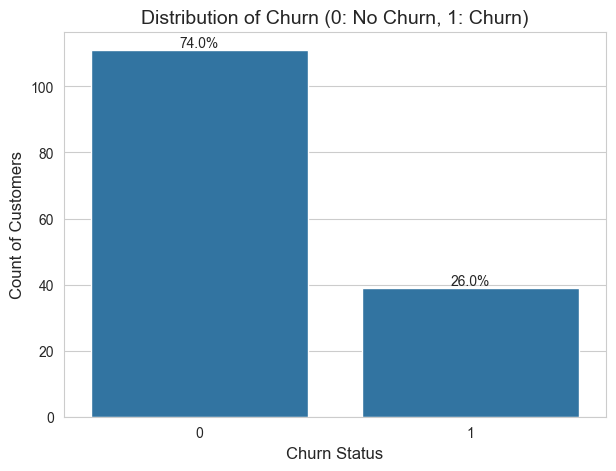


Churn Counts:
 Churn_Yes
0    111
1     39
Name: count, dtype: int64

Churn Percentage:
 Churn_Yes
0    74.0
1    26.0
Name: count, dtype: float64


In [131]:
sns.set_style("whitegrid")
plt.figure(figsize=(7, 5))
sns.countplot(x='Churn_Yes', data=df_gym)


plt.title('Distribution of Churn (0: No Churn, 1: Churn)', fontsize=14)
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Count of Customers', fontsize=12)

# Show the percentage on top of the bars for better insight
total = len(df_gym)
for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    plt.gca().annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

# Print the exact counts and percentage for confirmation
churn_counts = df_gym['Churn_Yes'].value_counts()
print("\nChurn Counts:\n", churn_counts)
print("\nChurn Percentage:\n", churn_counts / total * 100)

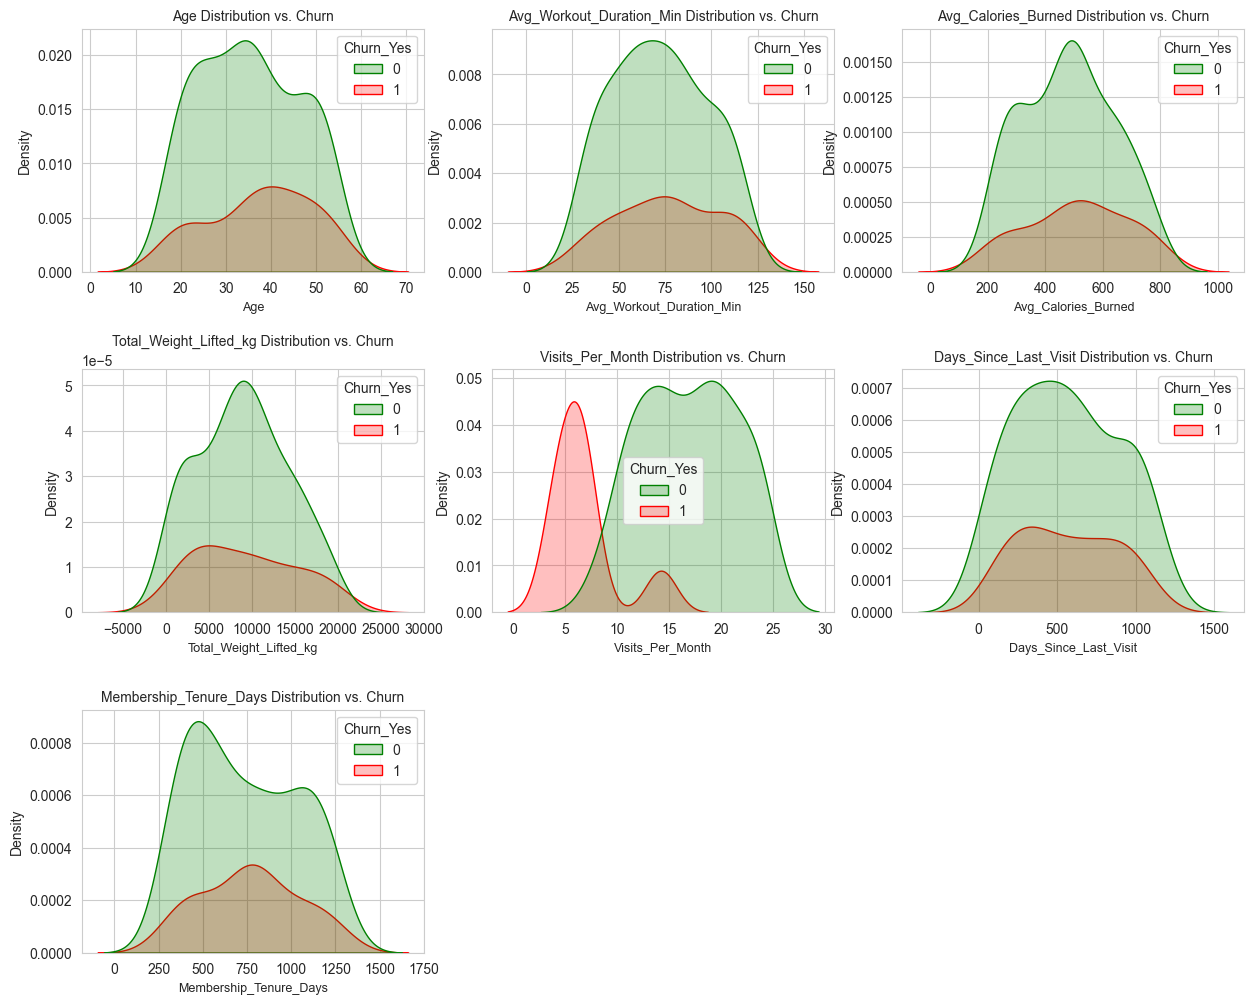

In [132]:
# Define the numerical columns we want to visualize
numerical_features = [
    'Age', 
    'Avg_Workout_Duration_Min', 
    'Avg_Calories_Burned', 
    'Total_Weight_Lifted_kg', 
    'Visits_Per_Month',
    'Days_Since_Last_Visit',
    'Membership_Tenure_Days'
]


plt.figure(figsize=(15, 12))
plt.subplots_adjust(hspace=0.4)
plot_number = 1

for feature in numerical_features:
    plt.subplot(3, 3, plot_number)
    
    # Use Kernel Density Estimate (KDE) plot to compare distributions between Churn groups
    sns.kdeplot(
        data=df_gym, 
        x=feature, 
        hue='Churn_Yes', 
        fill=True, 
        palette={0: 'green', 1: 'red'},
        legend=True
    )
    plt.title(f'{feature} Distribution vs. Churn', fontsize=10)
    plt.xlabel(feature, fontsize=9)
    plot_number += 1

plt.show()

In [133]:
scaling_cols = [
    'Age',
    'Avg_Workout_Duration_Min',
    'Avg_Calories_Burned',
    'Total_Weight_Lifted_kg',
    'Visits_Per_Month',
    'Days_Since_Last_Visit',
    'Membership_Tenure_Days'
]

sc = StandardScaler()

# calculates the mean and standard deviation (fit) and then scales the data (transform)

df_gym[scaling_cols] = sc.fit_transform(df_gym[scaling_cols])

In [134]:
# Separate Features (X) and Target (y)
# X contains all columns except the target column 'Churn_Yes'
X = df_gym.drop("Churn_Yes", axis=1)

# y contains the target column 'Churn_Yes'
y = df_gym["Churn_Yes"]

In [135]:
X_train , X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=69)
print("--- Data Split Summary ---")
print("Total number of samples:", len(df_gym))
print("X_train shape:" , X_train.shape)
print("X_test shape:" ,X_test.shape)

--- Data Split Summary ---
Total number of samples: 150
X_train shape: (120, 15)
X_test shape: (30, 15)


In [136]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

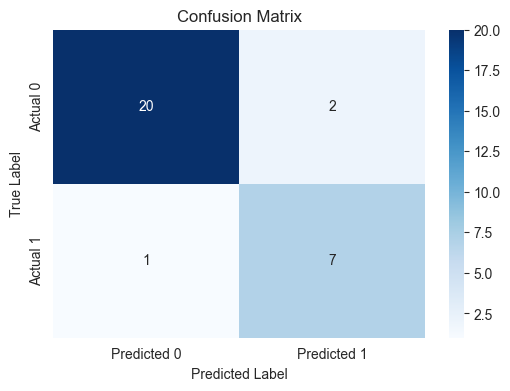

In [137]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted 0", 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [138]:
print("--- Classification Report --- \n", classification_report(y_test, y_pred))

--- Classification Report --- 
               precision    recall  f1-score   support

           0       0.95      0.91      0.93        22
           1       0.78      0.88      0.82         8

    accuracy                           0.90        30
   macro avg       0.87      0.89      0.88        30
weighted avg       0.91      0.90      0.90        30



--- Random Forest Classification Report ---
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        22
           1       1.00      0.88      0.93         8

    accuracy                           0.97        30
   macro avg       0.98      0.94      0.96        30
weighted avg       0.97      0.97      0.97        30



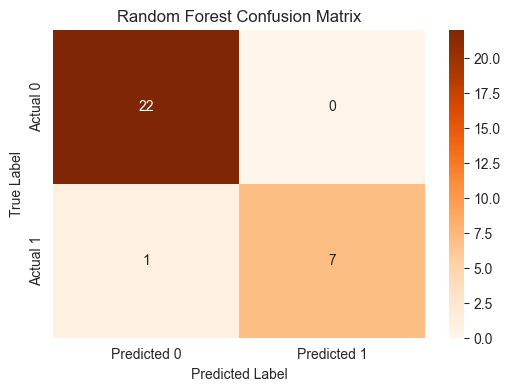

In [139]:
rf = RandomForestClassifier(n_estimators=100, random_state=69)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("--- Random Forest Classification Report ---\n", classification_report(y_test, y_pred_rf))
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

<style type="text/css">
#T_58529_row0_col1, #T_58529_row1_col1, #T_58529_row2_col0, #T_58529_row2_col1, #T_58529_row3_col1 {
  color: darkred;
  font-weight: bold;
}
</style>
<table id="T_58529">
  <thead>
    <tr>
      <th class="blank level0" >&nbsp;</th>
      <th id="T_58529_level0_col0" class="col_heading level0 col0" >Logistic Regression</th>
      <th id="T_58529_level0_col1" class="col_heading level0 col1" >Random Forest</th>
    </tr>
    <tr>
      <th class="index_name level0" >Metric</th>
      <th class="blank col0" >&nbsp;</th>
      <th class="blank col1" >&nbsp;</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th id="T_58529_level0_row0" class="row_heading level0 row0" >Accuracy (Overall)</th>
      <td id="T_58529_row0_col0" class="data row0 col0" >0.9000</td>
      <td id="T_58529_row0_col1" class="data row0 col1" >0.9667</td>
    </tr>
    <tr>
      <th id="T_58529_level0_row1" class="row_heading level0 row1" >Precision (Class 1 - CHURN)</th>
      <td id="T_58529_row1_col0" class="data row1 col0" >0.7778</td>
      <td id="T_58529_row1_col1" class="data row1 col1" >1.0000</td>
    </tr>
    <tr>
      <th id="T_58529_level0_row2" class="row_heading level0 row2" >Recall (Class 1 - CHURN)</th>
      <td id="T_58529_row2_col0" class="data row2 col0" >0.8750</td>
      <td id="T_58529_row2_col1" class="data row2 col1" >0.8750</td>
    </tr>
    <tr>
      <th id="T_58529_level0_row3" class="row_heading level0 row3" >F1-Score (Class 1 - CHURN)</th>
      <td id="T_58529_row3_col0" class="data row3 col0" >0.8235</td>
      <td id="T_58529_row3_col1" class="data row3 col1" >0.9333</td>
    </tr>
  </tbody>
</table>

The Random Forest model is superior for this problem.
It achieved 100% precision for the churn class, ensuring high confidence in intervention targeting

--------------

Executive Summary: Gym Churn Prediction Model

Actionable Recommendations
Based on the model's insights, the following strategies are recommended for immediate implementation:

Early Warning System (EWS): Target customers whose monthly visits fall below their personal average or a critical threshold (e.g., 4-5 visits/month).

Proactive Outreach: Implement mandatory, personalized staff contact (phone calls, not just texts) for any customer absent for 14 days or more to break the cycle of inactivity.

Commitment Incentives: Aggressively promote annual and quarterly membership plans as these types of commitment are proven to significantly reduce long-term churn risk.